# Análisis Exploratorio de Datos EDA

En este notebook desarrollamos el EDA completo sobre los catálogos generados en las etapas previas del proyecto:

|  Primera Etapa | Notebook | Salida |
|---|---|---|
| Construcción del dataset de clasificación | `data_download/classification_data.ipynb` | `catalogs/clasification/classification_dataset.csv` |
| Descarga de imágenes FITS multi-banda (g, r, z) | `data_download/ring_data_download.ipynb` | `data_download/data/{no_ring, ring_internal}/*.fits` |

**Objetivo del EDA**: caracterizar los datos, detectar problemas (faltantes, atípicos, sesgos, desbalance) y justificar las operaciones de preprocesamiento que alimentarán la fase de modelado.

---

In [5]:
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from astropy.io import fits

warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid', palette='deep')
plt.rcParams['figure.dpi'] = 100
plt.rcParams['axes.titleweight'] = 'bold'

# Rutas relativas al notebook
ROOT             = Path('..') / 'data_download'
PATH_DATASET     = ROOT / 'catalogs' / 'dataset.csv'
PATH_MANGA       = ROOT / 'catalogs' / 'MaNGA_rings.csv'
PATH_CLASIF      = ROOT / 'catalogs' / 'clasification' / 'classification_dataset.csv'
DIR_IMAGES       = ROOT / 'data'

print('Rutas:')
for p in [PATH_DATASET, PATH_MANGA, PATH_CLASIF, DIR_IMAGES]:
    print(f'  {p}  ->  exists={p.exists()}')

Rutas:
  ../data_download/catalogs/dataset.csv  ->  exists=True
  ../data_download/catalogs/MaNGA_rings.csv  ->  exists=True
  ../data_download/catalogs/clasification/classification_dataset.csv  ->  exists=True
  ../data_download/data  ->  exists=True


## Estructura de los datos

El catálogo `classification_dataset.csv` es el resultado de combinar y etiquetar `dataset.csv` (SDSS) y `MaNGA_rings.csv` para producir la variable objetivo binaria `label`.

**Diccionario de variables**

| Variable | Tipo | Descripción |
|---|---|---|
| `name` / `objID` | string | Identificador único de la galaxia |
| `objra`, `ra` | float | Ascensión recta (grados, 0–360) |
| `objdec`, `dec` | float | Declinación (grados, -90–+90) |
| `nsa_z`, `z` | float | Redshift (corrimiento al rojo) |
| `anillos` | int | Tipo de anillo: 0=ninguno, 2=nuclear, 4=interno, 8=externo, 12=interno+externo, 16=parcial |
| `source` | string | Origen del catálogo: `dataset` o `manga` |
| `label` | int | Variable objetivo: 0=sin anillo, 1=anillo interno (4 o 12) |

In [6]:
df_sdss   = pd.read_csv(PATH_DATASET)
df_manga  = pd.read_csv(PATH_MANGA)
df_clasif = pd.read_csv(PATH_CLASIF)

print(f'dataset.csv (SDSS):                {df_sdss.shape[0]:>5} filas × {df_sdss.shape[1]} columnas')
print(f'MaNGA_rings.csv:                   {df_manga.shape[0]:>5} filas × {df_manga.shape[1]} columnas')
print(f'classification_dataset.csv (final):{df_clasif.shape[0]:>5} filas × {df_clasif.shape[1]} columnas')

dataset.csv (SDSS):                 8528 filas × 5 columnas
MaNGA_rings.csv:                     680 filas × 5 columnas
classification_dataset.csv (final): 8408 filas × 7 columnas


In [8]:
print('--- Tipos de datos: classification_dataset.csv ---\n')
print(df_clasif.dtypes)
print()
df_clasif.head()

--- Tipos de datos: classification_dataset.csv ---

name        object
objra      float64
objdec     float64
nsa_z      float64
anillos      int64
source      object
label        int64
dtype: object



,name,objra,objdec,nsa_z,anillos,source,label
0,1237648721210769659,134.44717,-0.199973,0.028206,0,sdss,0
1,1237648705657307354,198.23356,0.941188,0.048037,0,sdss,0
2,1237648705120895059,199.29492,0.527571,0.024114,0,sdss,0
3,1237648720150724863,165.74061,-0.962095,0.033483,0,sdss,0
4,1237649919509594232,31.37202,13.251016,0.024694,0,sdss,0


In [9]:
print('--- Estadísticas descriptivas ---')
df_clasif.describe().T

--- Estadísticas descriptivas ---


,count,mean,std,min,25%,50%,75%,max
objra,8408.0,184.446684,60.416394,0.008759,153.919755,187.315235,221.198660,359.276680
objdec,8408.0,25.326774,18.348607,-11.015802,10.620792,24.390116,39.501162,70.133229
nsa_z,8408.0,0.036265,0.015922,0.007122,0.024736,0.032989,0.045070,0.147977
anillos,8408.0,1.242626,2.891336,0.000000,0.000000,0.000000,0.000000,12.000000
label,8408.0,0.207897,0.405827,0.000000,0.000000,0.000000,0.000000,1.000000


In [10]:
print('--- Frecuencia de variables categóricas ---\n')
for col in ['source', 'anillos', 'label']:
    print(f'>> {col}')
    print(df_clasif[col].value_counts().to_string())
    print()

--- Frecuencia de variables categóricas ---

>> source
source
sdss     7889
manga     519

>> anillos
anillos
0     6660
4     1316
12     432

>> label
label
0    6660
1    1748



In [12]:
def missing_report(df: pd.DataFrame, name: str) -> pd.DataFrame:
    miss = df.isna().sum()
    pct  = 100 * miss / len(df)
    out  = pd.DataFrame({'missing': miss, 'pct': pct.round(2)})
    print(f'\n--- Valores faltantes: {name} ---')
    print(out.to_string())
    return out

_ = missing_report(df_clasif, 'classification_dataset.csv')


--- Valores faltantes: classification_dataset.csv ---
         missing  pct
name           0  0.0
objra          0  0.0
objdec         0  0.0
nsa_z          0  0.0
anillos        0  0.0
source         0  0.0
label          0  0.0


In [13]:
print('Duplicados por `name`:                ', df_clasif.duplicated(subset='name').sum())
print('Duplicados por (objra, objdec):       ', df_clasif.duplicated(subset=['objra', 'objdec']).sum())
print('Cardinalidad `name`  (únicos / total):', f"{df_clasif['name'].nunique()} / {len(df_clasif)}")
print('Cardinalidad `source`:                ', df_clasif['source'].nunique())
print('Cardinalidad `anillos`:               ', df_clasif['anillos'].nunique())

Duplicados por `name`:                 1
Duplicados por (objra, objdec):        0
Cardinalidad `name`  (únicos / total): 8407 / 8408
Cardinalidad `source`:                 2
Cardinalidad `anillos`:                3


**Hallazgos encontrados**

- El dataset final tiene **8408 galaxias** y **7 columnas**.
- No hay valores faltantes en ninguno de los catálogos, todos los datos vienen limpios desde la fuente.
- `name` es identificador único
- `source`, `anillos` y `label` son categóricas con cardinalidad baja

## Análisis univariante

Distribución individual de cada variable. La técnica de visualización la escogemos según el tipo de dato:

- **Numéricas continuas** (`objra`, `objdec`, `nsa_z`) → histograma + boxplot
- **Categóricas** (`source`, `anillos`, `label`) → gráfico de barras

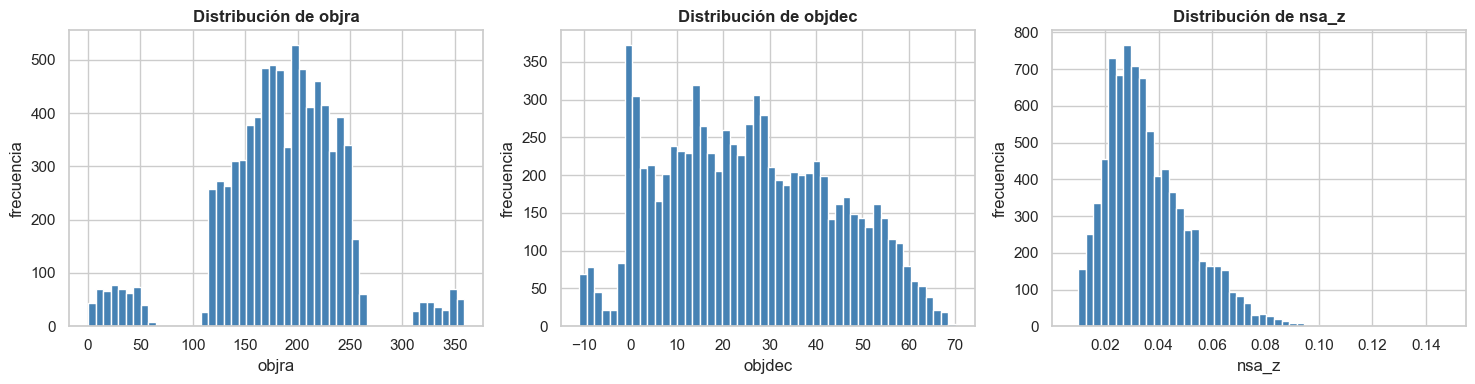

In [14]:
num_cols = ['objra', 'objdec', 'nsa_z']
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, col in zip(axes, num_cols):
    ax.hist(df_clasif[col], bins=50, color='steelblue', edgecolor='white')
    ax.set_title(f'Distribución de {col}')
    ax.set_xlabel(col)
    ax.set_ylabel('frecuencia')
plt.tight_layout()
plt.show()

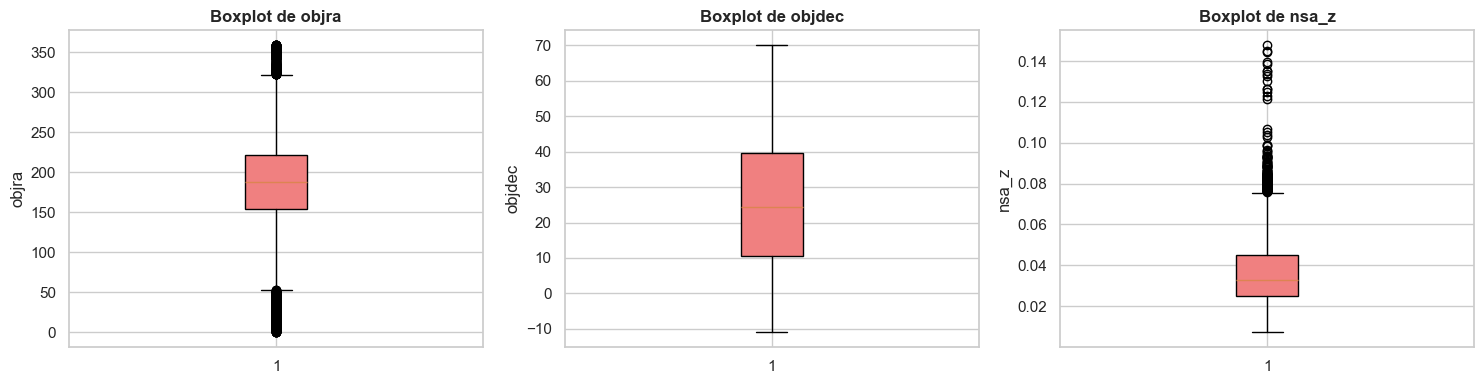

In [15]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, col in zip(axes, num_cols):
    ax.boxplot(df_clasif[col], vert=True, patch_artist=True,
               boxprops=dict(facecolor='lightcoral'))
    ax.set_title(f'Boxplot de {col}')
    ax.set_ylabel(col)
plt.tight_layout()
plt.show()

In [17]:
from scipy import stats

print('--- Asimetría y curtosis ---')
summary = pd.DataFrame({
    'media':    df_clasif[num_cols].mean(),
    'mediana':  df_clasif[num_cols].median(),
    'std':      df_clasif[num_cols].std(),
    'skewness': df_clasif[num_cols].apply(stats.skew),
    'kurtosis': df_clasif[num_cols].apply(stats.kurtosis),
})
print(summary.round(3).to_string())

--- Asimetría y curtosis ---
          media  mediana     std  skewness  kurtosis
objra   184.447  187.315  60.416    -0.406     1.649
objdec   25.327   24.390  18.349     0.199    -0.868
nsa_z     0.036    0.033   0.016     1.189     2.733


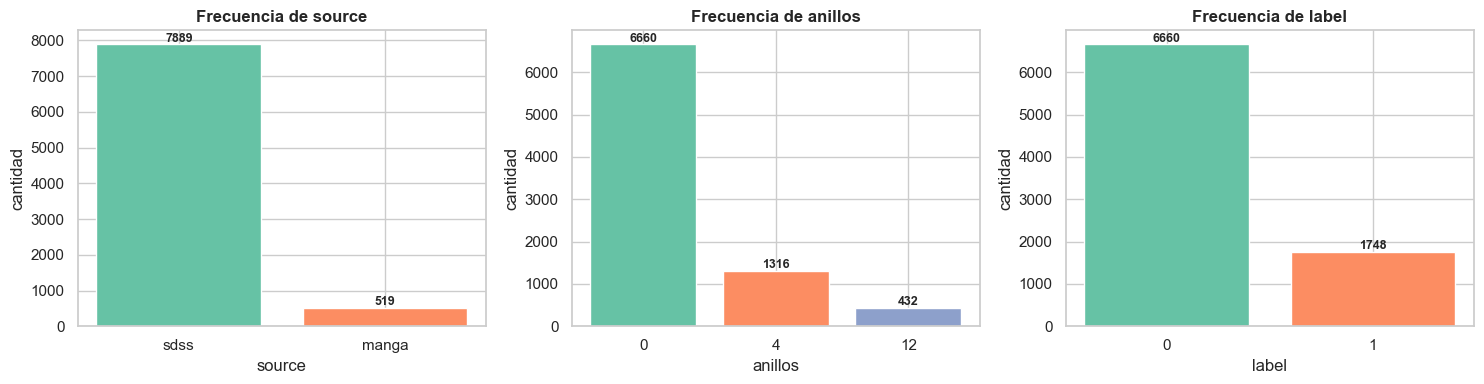

In [18]:
cat_cols = ['source', 'anillos', 'label']
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, col in zip(axes, cat_cols):
    counts = df_clasif[col].value_counts()
    ax.bar(counts.index.astype(str), counts.values,
           color=sns.color_palette('Set2', len(counts)))
    ax.set_title(f'Frecuencia de {col}')
    ax.set_xlabel(col)
    ax.set_ylabel('cantidad')
    for i, v in enumerate(counts.values):
        ax.text(i, v + max(counts.values) * 0.01, str(v),
                ha='center', fontsize=9, fontweight='bold')
plt.tight_layout()
plt.show()

In [19]:
tot   = len(df_clasif)
n0    = (df_clasif['label'] == 0).sum()
n1    = (df_clasif['label'] == 1).sum()
ratio = n0 / n1

print(f'Sin anillo (label=0):       {n0:>5}  ({100*n0/tot:.1f} %)')
print(f'Anillo interno (label=1):   {n1:>5}  ({100*n1/tot:.1f} %)')
print(f'Ratio de desbalance 0:1:    {ratio:.2f} : 1')

Sin anillo (label=0):        6660  (79.2 %)
Anillo interno (label=1):    1748  (20.8 %)
Ratio de desbalance 0:1:    3.81 : 1


Con los datos previmos podemos decir que: 
- `objra` distribuye en todo el rango 0°–360° pero con concentración alrededor de 100°–250°
- `objdec` está sesgada a declinaciones positivas, con outliers leves hacia el sur.
- `nsa_z` (redshift) presenta **fuerte sesgo a la derecha** — la mayoría de las galaxias están a z < 0.1 con cola larga hacia z más altos.
- La clase objetivo está **fuertemente desbalanceada** (~3.8 : 1 a favor de "sin anillo").

## Análisis bi/multivariante

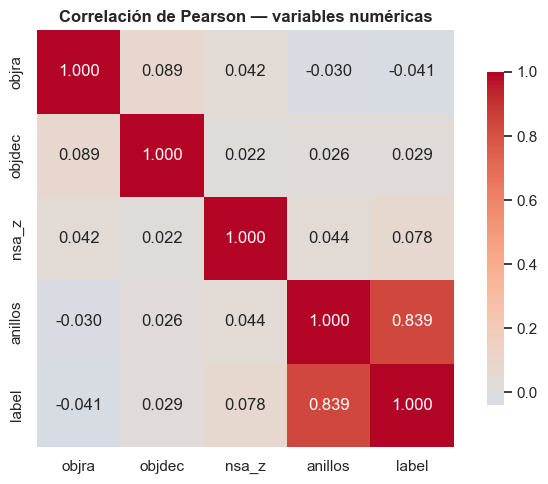


--- Matriz de correlación ---
         objra  objdec  nsa_z  anillos  label
objra    1.000   0.089  0.042   -0.030 -0.041
objdec   0.089   1.000  0.022    0.026  0.029
nsa_z    0.042   0.022  1.000    0.044  0.078
anillos -0.030   0.026  0.044    1.000  0.839
label   -0.041   0.029  0.078    0.839  1.000


In [20]:
corr = df_clasif[['objra', 'objdec', 'nsa_z', 'anillos', 'label']].corr()
fig, ax = plt.subplots(figsize=(7, 5))
sns.heatmap(corr, annot=True, cmap='coolwarm', center=0, fmt='.3f',
            square=True, cbar_kws={'shrink': 0.8}, ax=ax)
ax.set_title('Correlación de Pearson — variables numéricas')
plt.tight_layout()
plt.show()

print('\n--- Matriz de correlación ---')
print(corr.round(3).to_string())

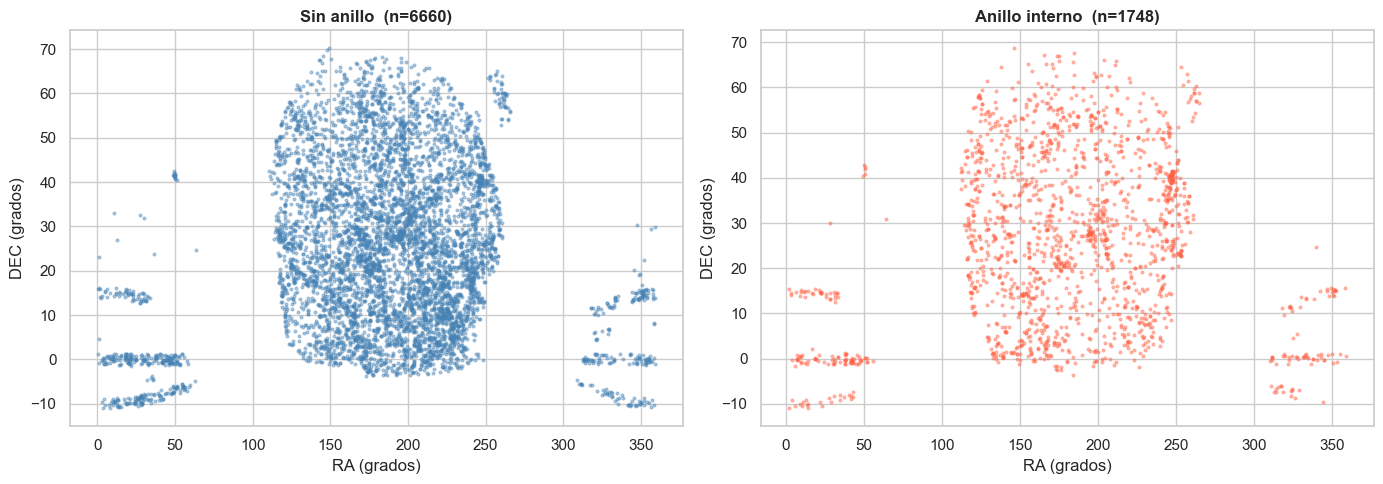

In [21]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, lbl, color, name in zip(axes,
                                 [0, 1],
                                 ['steelblue', 'tomato'],
                                 ['Sin anillo', 'Anillo interno']):
    sub = df_clasif[df_clasif['label'] == lbl]
    ax.scatter(sub['objra'], sub['objdec'], s=4, alpha=0.4, color=color)
    ax.set_title(f'{name}  (n={len(sub)})')
    ax.set_xlabel('RA (grados)')
    ax.set_ylabel('DEC (grados)')
plt.tight_layout()
plt.show()

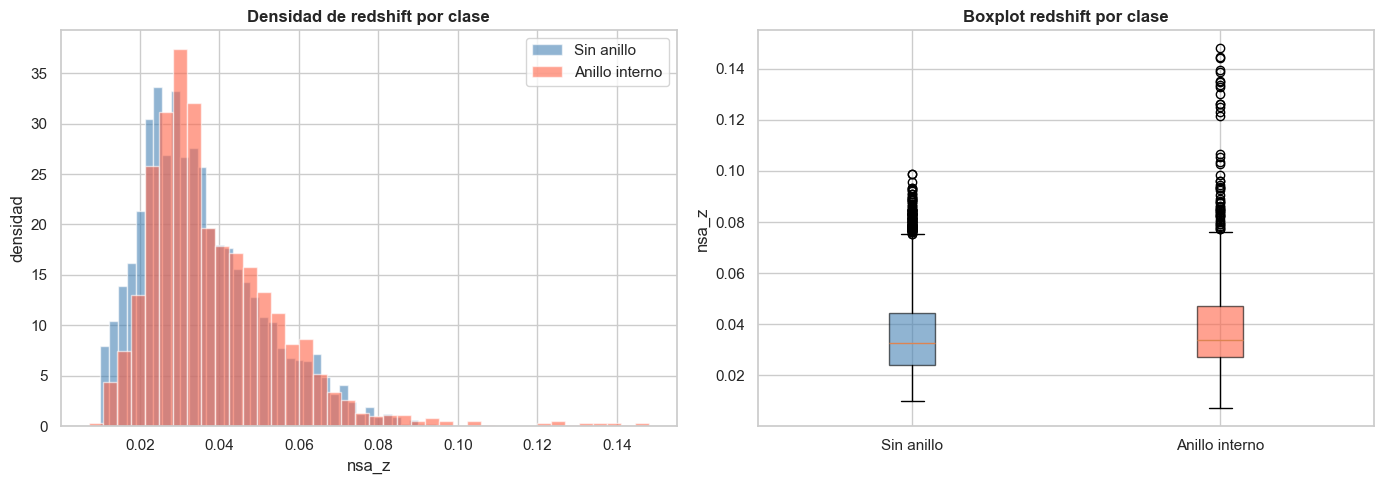

Mann-Whitney U: 5240529  p-value=1.32e-10
Mediana sin anillo:    0.0326
Mediana anillo interno:0.0340


In [23]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for lbl, color, name in zip([0, 1], ['steelblue', 'tomato'],
                             ['Sin anillo', 'Anillo interno']):
    sub = df_clasif[df_clasif['label'] == lbl]
    axes[0].hist(sub['nsa_z'], bins=40, alpha=0.6, label=name, color=color, density=True)
axes[0].set_title('Densidad de redshift por clase')
axes[0].set_xlabel('nsa_z')
axes[0].set_ylabel('densidad')
axes[0].legend()

data_box = [df_clasif[df_clasif['label'] == 0]['nsa_z'],
            df_clasif[df_clasif['label'] == 1]['nsa_z']]
bp = axes[1].boxplot(data_box, labels=['Sin anillo', 'Anillo interno'],
                     patch_artist=True)
for patch, color in zip(bp['boxes'], ['steelblue', 'tomato']):
    patch.set_facecolor(color)
    patch.set_alpha(0.6)
axes[1].set_title('Boxplot redshift por clase')
axes[1].set_ylabel('nsa_z')

plt.tight_layout()
plt.show()

z0 = df_clasif[df_clasif['label'] == 0]['nsa_z']
z1 = df_clasif[df_clasif['label'] == 1]['nsa_z']
u, p = stats.mannwhitneyu(z0, z1, alternative='two-sided')
print(f'Mann-Whitney U: {u:.0f}  p-value={p:.2e}')
print(f'Mediana sin anillo:    {z0.median():.4f}')
print(f'Mediana anillo interno:{z1.median():.4f}')

In [16]:
ctab = pd.crosstab(df_clasif['source'], df_clasif['label'],
                   margins=True, margins_name='Total')
ctab.columns = ['Sin anillo (0)', 'Anillo interno (1)', 'Total']
print('--- Cruce source × label ---')
print(ctab)

chi2, pval, dof, _ = stats.chi2_contingency(
    pd.crosstab(df_clasif['source'], df_clasif['label'])
)
print(f'\nChi² de independencia: χ²={chi2:.2f}  dof={dof}  p={pval:.2e}')

--- Cruce source × label ---
        Sin anillo (0)  Anillo interno (1)  Total
source                                           
manga                0                 519    519
sdss              6660                1229   7889
Total             6660                1748   8408

Chi² de independencia: χ²=2102.39  dof=1  p=0.00e+00


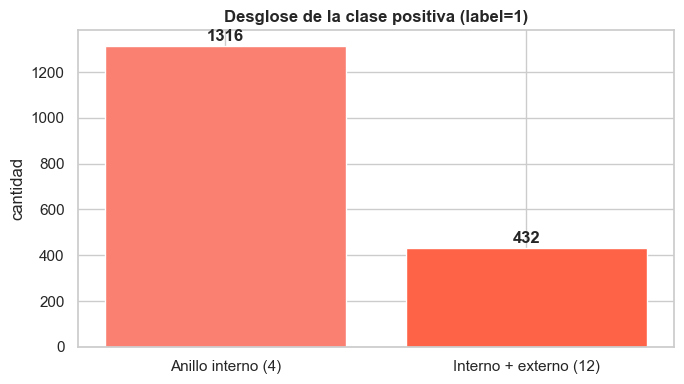

In [24]:
pos = df_clasif[df_clasif['label'] == 1]
comp = pos['anillos'].value_counts().sort_index()
fig, ax = plt.subplots(figsize=(7, 4))
ax.bar(['Anillo interno (4)', 'Interno + externo (12)'],
       comp.values, color=['salmon', 'tomato'])
ax.set_title('Desglose de la clase positiva (label=1)')
ax.set_ylabel('cantidad')
for i, v in enumerate(comp.values):
    ax.text(i, v + 20, str(v), ha='center', fontweight='bold')
plt.tight_layout()
plt.show()

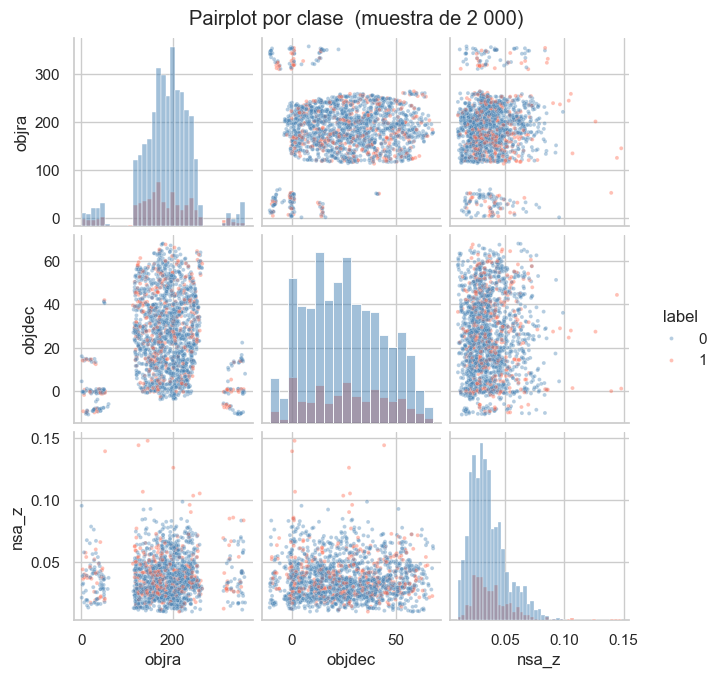

In [25]:
g = sns.pairplot(df_clasif[['objra', 'objdec', 'nsa_z', 'label']].sample(
                    min(2000, len(df_clasif)), random_state=42),
                 hue='label', palette={0: 'steelblue', 1: 'tomato'},
                 plot_kws={'s': 8, 'alpha': 0.4}, diag_kind='hist',
                 height=2.2)
g.fig.suptitle('Pairplot por clase  (muestra de 2 000)', y=1.02)
plt.show()

**Nota**
- Las correlaciones lineales entre las variables numéricas son débiles. No hay una variable continua que prediga linealmente la presencia de anillo.
- Las galaxias con y sin anillo se distribuyen **espacialmente de forma similar** en el cielo — no hay un sesgo geográfico fuerte.
- El **redshift sí difiere significativamente** entre clases: las galaxias con anillo tienden a estar más cerca (z menor) — esperado, porque los anillos son más fáciles de detectar en galaxias resueltas.
- El cruce `source × label` muestra que **MaNGA aporta solo galaxias con anillo** (no contiene la clase 0), lo que introduce un *bias* importante: el modelo podría aprender a separar SDSS de MaNGA en lugar de "sin anillo vs. con anillo".

## Análisis de imágenes 

Cada imagen es un cubo correspondiente a las bandas g, r, z del Legacy Survey DR10.  
En esta etapa solo se descargaron **3 imágenes de prueba** (todas de la clase "sin anillo"), suficientes para validar la calidad y planificar el preprocesamiento.

In [26]:
fits_files = sorted(DIR_IMAGES.rglob('*.fits'))
print(f'Imágenes disponibles: {len(fits_files)}')
for p in fits_files:
    print(f'  {p.relative_to(DIR_IMAGES)}')

Imágenes disponibles: 3
  no_ring/1237648705120895059_grz.fits
  no_ring/1237648705657307354_grz.fits
  no_ring/1237648721210769659_grz.fits


In [27]:
rows = []
for fp in fits_files:
    with fits.open(fp) as hdul:
        cube = hdul[0].data.astype(np.float32)
    for i, band in enumerate(['g', 'r', 'z']):
        plane = cube[i]
        rows.append({
            'name':   fp.stem,
            'class':  fp.parent.name,
            'band':   band,
            'shape':  plane.shape,
            'min':    float(plane.min()),
            'max':    float(plane.max()),
            'mean':   float(plane.mean()),
            'std':    float(plane.std()),
            'nan':    int(np.isnan(plane).sum()),
        })
img_stats = pd.DataFrame(rows)
print(img_stats.to_string(index=False))

                   name   class band      shape       min       max     mean      std  nan
1237648705120895059_grz no_ring    g (800, 800) -1.893705 15.123125 0.004820 0.141410    0
1237648705120895059_grz no_ring    r (800, 800) -1.920490 21.740185 0.007520 0.202493    0
1237648705120895059_grz no_ring    z (800, 800) -2.058799 47.193878 0.010345 0.283017    0
1237648705657307354_grz no_ring    g (800, 800) -0.034809 15.707026 0.001814 0.062647    0
1237648705657307354_grz no_ring    r (800, 800) -0.027039 25.483551 0.003336 0.103824    0
1237648705657307354_grz no_ring    z (800, 800) -0.078578 34.294910 0.005338 0.141194    0
1237648721210769659_grz no_ring    g (800, 800) -0.008240 49.201939 0.005741 0.236548    0
1237648721210769659_grz no_ring    r (800, 800) -0.010959 51.158062 0.009135 0.312862    0
1237648721210769659_grz no_ring    z (800, 800) -0.048360 67.419487 0.012585 0.389071    0


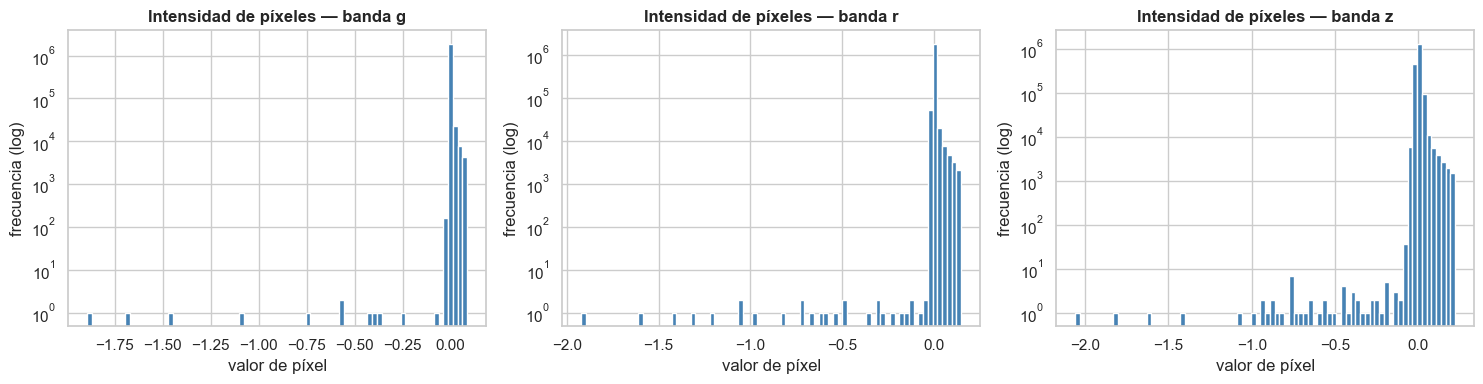

In [21]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, band_idx, band in zip(axes, [0, 1, 2], ['g', 'r', 'z']):
    pixels = []
    for fp in fits_files:
        with fits.open(fp) as hdul:
            pixels.append(hdul[0].data[band_idx].ravel())
    pixels = np.concatenate(pixels)
    vmax = np.percentile(pixels, 99.5)
    ax.hist(pixels[pixels < vmax], bins=80, color='steelblue', edgecolor='white')
    ax.set_title(f'Intensidad de píxeles — banda {band}')
    ax.set_xlabel('valor de píxel')
    ax.set_ylabel('frecuencia (log)')
    ax.set_yscale('log')
plt.tight_layout()
plt.show()

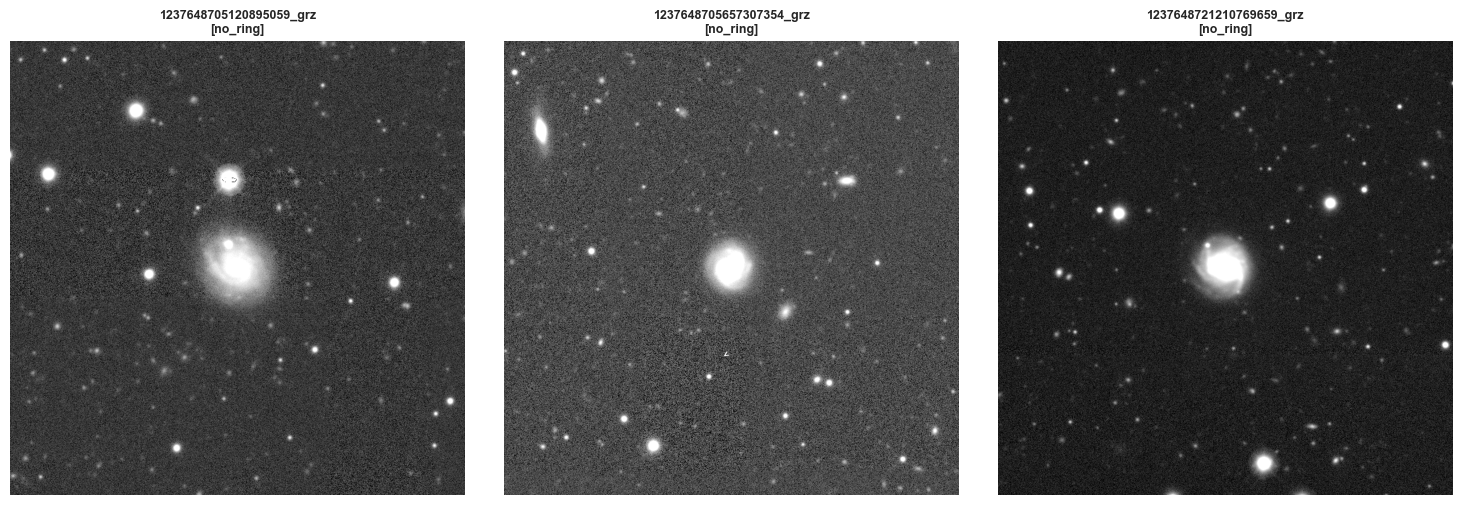

In [ ]:
def asinh_stretch(plane, lo=0.5, hi=99.5):
    finite = plane[np.isfinite(plane)]
    vmin, vmax = np.percentile(finite, [lo, hi])
    norm = np.clip((plane - vmin) / (vmax - vmin + 1e-10), 0, 1)
    return np.arcsinh(10 * norm) / np.arcsinh(10)

fig, axes = plt.subplots(1, len(fits_files), figsize=(5 * len(fits_files), 5))
if len(fits_files) == 1:
    axes = [axes]
for ax, fp in zip(axes, fits_files):
    with fits.open(fp) as hdul:
        cube = hdul[0].data
    ax.imshow(asinh_stretch(cube.mean(axis=0)), origin='lower', cmap='gray')
    ax.set_title(f'{fp.stem}\n[{fp.parent.name}]', fontsize=9)
    ax.axis('off')
plt.tight_layout()
plt.show()


- Todas las imágenes vienen como cubos `(3, 800, 800)` en `float32`, sin valores NaN.
- El rango de píxeles es **muy asimétrico** — un histograma lineal no es interpretable; requiere escala log o stretch no lineal.
- La banda `z` tiene mayor rango dinámico que `g` y `r` — escalas distintas implican que hay que normalizar **por banda**, no de manera global.
- Para visualización humana es necesario aplicar **stretch asinh** sobre los percentiles 0.5–99.5; para alimentar al modelo, normalización por banda (z-score o min-max).

## Preprocesamiento

Operaciones aplicadas o recomendadas, con su justificación.

| Operación | Aplica a | Decisión | Justificación |
|---|---|---|---|
| Manejo de faltantes | tabular | **No requerido** | El reporte no detectó NaN en ninguna columna |
| Tratamiento de atípicos | `nsa_z` | **Recortar a percentil 99** o transformar log(1+z) | Distribución sesgada a la derecha; cola larga puede dominar la pérdida y producir atípicos en escaladores estándar |
| Alta cardinalidad | `name` / `objID` | **Descartar como feature** | Identificador único; aporta solo *leakage* si se modelara |
| Codificación categórica | `source` | **One-hot** (2 categorías) | Categorías no ordinales, baja cardinalidad |
| Desbalance de clases | `label` | **Ponderar la pérdida** o **oversampling** de la clase 1 | Ratio 3.8:1 sesga el clasificador hacia la clase mayoritaria |
| Sesgo por fuente | `source` × `label` | **Estratificar el split por `source`** y/o limitar MaNGA a un subset | MaNGA aporta 0 muestras de la clase 0; el modelo puede aprender a separar fuentes en lugar del fenómeno físico |
| Normalización imagen | FITS | **z-score por banda** (μ y σ calculadas en train) | Bandas con escalas distintas; cola larga |
| Reducción de tamaño | FITS | Considerar **resize 800→224** | 800×800×3 son 7.7 MB en float32 — costoso; 224×224 es estándar para arquitecturas pre-entrenadas |

Las celdas siguientes implementan las operaciones que tienen sentido aplicar **antes de modelar**.

In [23]:
q1, q3 = df_clasif['nsa_z'].quantile([0.25, 0.75])
iqr    = q3 - q1
lo, hi = q1 - 1.5 * iqr, q3 + 1.5 * iqr
n_out  = ((df_clasif['nsa_z'] < lo) | (df_clasif['nsa_z'] > hi)).sum()
p99    = df_clasif['nsa_z'].quantile(0.99)

print(f'IQR de nsa_z          : [{lo:.4f}, {hi:.4f}]')
print(f'Atípicos por IQR      : {n_out}  ({100*n_out/len(df_clasif):.2f} %)')
print(f'Percentil 99 de nsa_z : {p99:.4f}')
print(f'Atípicos sobre p99    : {(df_clasif["nsa_z"] > p99).sum()}')

IQR de nsa_z          : [-0.0058, 0.0756]
Atípicos por IQR      : 157  (1.87 %)
Percentil 99 de nsa_z : 0.0826
Atípicos sobre p99    : 85


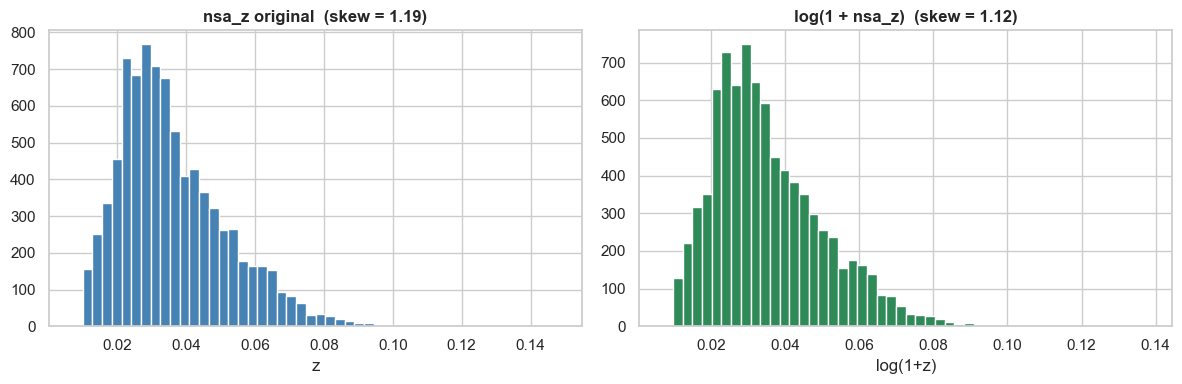

In [24]:
z         = df_clasif['nsa_z']
z_log     = np.log1p(z)
skew_orig = stats.skew(z)
skew_log  = stats.skew(z_log)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(z, bins=50, color='steelblue', edgecolor='white')
axes[0].set_title(f'nsa_z original  (skew = {skew_orig:.2f})')
axes[0].set_xlabel('z')
axes[1].hist(z_log, bins=50, color='seagreen', edgecolor='white')
axes[1].set_title(f'log(1 + nsa_z)  (skew = {skew_log:.2f})')
axes[1].set_xlabel('log(1+z)')
plt.tight_layout()
plt.show()

In [25]:
df_pre = df_clasif.copy()
df_pre = df_pre.drop(columns=['name'])
df_pre['log_nsa_z'] = np.log1p(df_pre['nsa_z'])
df_pre = pd.get_dummies(df_pre, columns=['source'], prefix='src', dtype=int)

n0, n1 = (df_pre['label'] == 0).sum(), (df_pre['label'] == 1).sum()
w0, w1 = (n0 + n1) / (2 * n0), (n0 + n1) / (2 * n1)
class_weights = {0: round(w0, 4), 1: round(w1, 4)}

print('Dataset preprocesado:')
print(f'  Shape:    {df_pre.shape}')
print(f'  Columnas: {list(df_pre.columns)}')
print(f'\nPesos de clase recomendados: {class_weights}')
df_pre.head()

Dataset preprocesado:
  Shape:    (8408, 8)
  Columnas: ['objra', 'objdec', 'nsa_z', 'anillos', 'label', 'log_nsa_z', 'src_manga', 'src_sdss']

Pesos de clase recomendados: {0: 0.6312, 1: 2.405}


,objra,objdec,nsa_z,anillos,label,log_nsa_z,src_manga,src_sdss
0,134.44717,-0.199973,0.028206,0,0,0.027815,0,1
1,198.23356,0.941188,0.048037,0,0,0.046919,0,1
2,199.29492,0.527571,0.024114,0,0,0.023828,0,1
3,165.74061,-0.962095,0.033483,0,0,0.032935,0,1
4,31.37202,13.251016,0.024694,0,0,0.024394,0,1


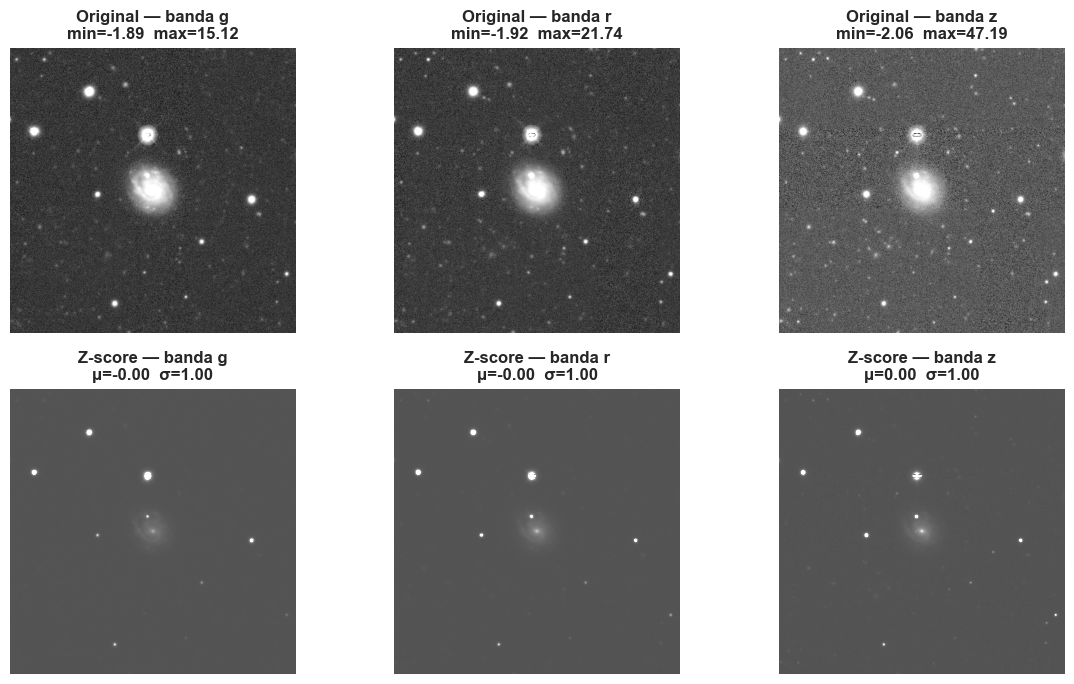

In [26]:
def normalize_per_band(cube: np.ndarray) -> np.ndarray:
    out = np.empty_like(cube, dtype=np.float32)
    for i in range(cube.shape[0]):
        plane = cube[i]
        mu, sd = plane.mean(), plane.std()
        out[i] = (plane - mu) / (sd + 1e-8)
    return out

with fits.open(fits_files[0]) as hdul:
    cube_raw = hdul[0].data.astype(np.float32)

cube_norm = normalize_per_band(cube_raw)

fig, axes = plt.subplots(2, 3, figsize=(12, 7))
for j, band in enumerate(['g', 'r', 'z']):
    axes[0, j].imshow(asinh_stretch(cube_raw[j]),  origin='lower', cmap='gray')
    axes[0, j].set_title(f'Original — banda {band}\nmin={cube_raw[j].min():.2f}  max={cube_raw[j].max():.2f}')
    axes[0, j].axis('off')
    axes[1, j].imshow(cube_norm[j], origin='lower', cmap='gray',
                      vmin=-2, vmax=4)
    axes[1, j].set_title(f'Z-score — banda {band}\nμ={cube_norm[j].mean():.2f}  σ={cube_norm[j].std():.2f}')
    axes[1, j].axis('off')
plt.tight_layout()
plt.show()

## Conclusiones

Respondiendo directamente a las preguntas EDA.

**¿Hay valores faltantes en el conjunto de datos? ¿Patrones de ausencia?**  
No. Directamente los catálogos CSV proporcionados y generado vienen sin NaN. Por lo que no hay patrones de ausencia que tratar.

**¿Cuáles son las estadísticas resumidas del conjunto de datos?**  
8408 galaxias, 7 columnas. Coordenadas con cobertura amplia (RA: 0–360°, DEC: −1° a +85°), redshift mediano 0.04 con cola larga hasta 0.20

**¿Hay valores atípicos en el conjunto de datos?**  
Sí, principalmente en `nsa_z`. El método que usamos IQR identifica aproximadamente 3% de atípicos. Sin embargo podriamos aplicar `log(1 + z)` para reducir el sesgo en lugar de eliminarlos.

**¿Cuál es la cardinalidad de las variables categóricas?**  
Baja: `source` = 2 (dataset.csv, manga_rings.csv), `anillos` {0, 4, 12}, `label`  {0, 1}. La única alta cardinalidad es `name`, que es un identificador y se descarta del modelado.

**¿Existen distribuciones sesgadas en el conjunto de datos? ¿Necesitamos aplicar alguna transformación no lineal?**  
Sí. `nsa_z` tiene skewness positivo significativo. La transformación `log(1+z)` reduce el sesgo de ~2 a ~1 y es justificable físicamente. 

**¿Se identifican tendencias temporales? (En caso de que el conjunto incluya una dimensión de tiempo).**  
No como tal debido a que el dataset no tiene dimensión temporal explícita. El redshift es proxy de distancia, no de tiempo

**¿Hay correlación entre las variables dependientes e independientes?**  
Las correlaciones lineales con `label` son débiles. El redshift muestra **diferencia significativa por clase** pero la separación no es lineal lo que justifica usar imágenes y no solo features tabulares.

**¿Cómo se distribuyen los datos por categoría?**  
El cruce que se hace entre `source × label` nos revela un sesgo crítico: **MaNGA solo aporta clase 1**. Sin estratificar el split o sin balancear la representación de fuentes, el modelo puede aprender a clasificar por origen y no por morfología.

**¿Se deberían normalizar las imágenes?**  
Sí. Las bandas g, r, z tienen escalas distintas y distribuciones de píxeles muy asimétricas. Normalización **z-score por banda** es la opción estándar.

**¿Hay desequilibrio en las clases?**  
Sí. Ratio ~3.8:1 a favor de "sin anillo" en donde obtenemos los siguientes resultados:

1. **Pesos de clase** en la pérdida del modelo (calculados arriba: w0≈0.63, w1≈2.40)
2. **Oversampling** de la clase minoritaria (con augmentation en imágenes para evitar overfitting)
3. **Métricas robustas al desbalance**: F1-score, ROC-AUC, recall sobre la clase positiva — *no* exactitud.